In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib

In [2]:
# carga de datos
# normales
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

# escalados
X_train_scaled = pd.read_csv("../data/processed/X_train_scaled.csv")
X_test_scaled = pd.read_csv("../data/processed/X_test_scaled.csv")

# target
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [3]:
# funcion para hacer la evaluación
results = []
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": model.__class__.__name__,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print(f"Model: {model.__class__.__name__}")
    print("-" * 40)

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc_auc)

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

In [4]:
# Logistic regression (escalado)
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

evaluate_model(
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

Model: LogisticRegression
----------------------------------------
Accuracy: 0.7235
Precision: 0.4016282225237449
Recall: 0.7254901960784313
F1 Score: 0.5170305676855895
ROC-AUC: 0.7999402650507439

Confusion Matrix
[[1151  441]
 [ 112  296]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1592
           1       0.40      0.73      0.52       408

    accuracy                           0.72      2000
   macro avg       0.66      0.72      0.66      2000
weighted avg       0.81      0.72      0.75      2000



In [5]:
# decision tree (sin escalado)
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

evaluate_model(
    dt,
    X_train,
    X_test,
    y_train,
    y_test
)

Model: DecisionTreeClassifier
----------------------------------------
Accuracy: 0.8
Precision: 0.5101522842639594
Recall: 0.49264705882352944
F1 Score: 0.5012468827930174
ROC-AUC: 0.6857079515223176

Confusion Matrix
[[1399  193]
 [ 207  201]]

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.88      0.87      1592
           1       0.51      0.49      0.50       408

    accuracy                           0.80      2000
   macro avg       0.69      0.69      0.69      2000
weighted avg       0.80      0.80      0.80      2000



In [8]:
# Random forest (sin escalado)
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

evaluate_model(
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

Model: RandomForestClassifier
----------------------------------------
Accuracy: 0.8675
Precision: 0.8356807511737089
Recall: 0.4362745098039216
F1 Score: 0.573268921095008
ROC-AUC: 0.8625934513252538

Confusion Matrix
[[1557   35]
 [ 230  178]]

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1592
           1       0.84      0.44      0.57       408

    accuracy                           0.87      2000
   macro avg       0.85      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [6]:
# XGBoost (sin escalado)
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

evaluate_model(
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Model: XGBClassifier
----------------------------------------
Accuracy: 0.864
Precision: 0.7556390977443609
Recall: 0.49264705882352944
F1 Score: 0.5964391691394659
ROC-AUC: 0.8725413218051039

Confusion Matrix
[[1527   65]
 [ 207  201]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1592
           1       0.76      0.49      0.60       408

    accuracy                           0.86      2000
   macro avg       0.82      0.73      0.76      2000
weighted avg       0.86      0.86      0.85      2000



In [9]:
# resultados bien mostrados
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,XGBClassifier,0.8640,0.755639,0.492647,0.596439,0.872541
3,RandomForestClassifier,0.8675,0.835681,0.436275,0.573269,0.862593
0,LogisticRegression,0.7235,0.401628,0.725490,0.517031,0.799940
1,DecisionTreeClassifier,0.8000,0.510152,0.492647,0.501247,0.685708


# RANDOM FOREST

In [10]:
# Randmom Forest feature importance
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
2,age,0.167865
5,numofproducts,0.110814
4,balance,0.103517
8,estimatedsalary,0.097093
10,point_earned,0.095664
0,creditscore,0.093904
3,tenure,0.056763
9,satisfaction_score,0.041237
7,isactivemember,0.034530
12,geography_Germany,0.029881


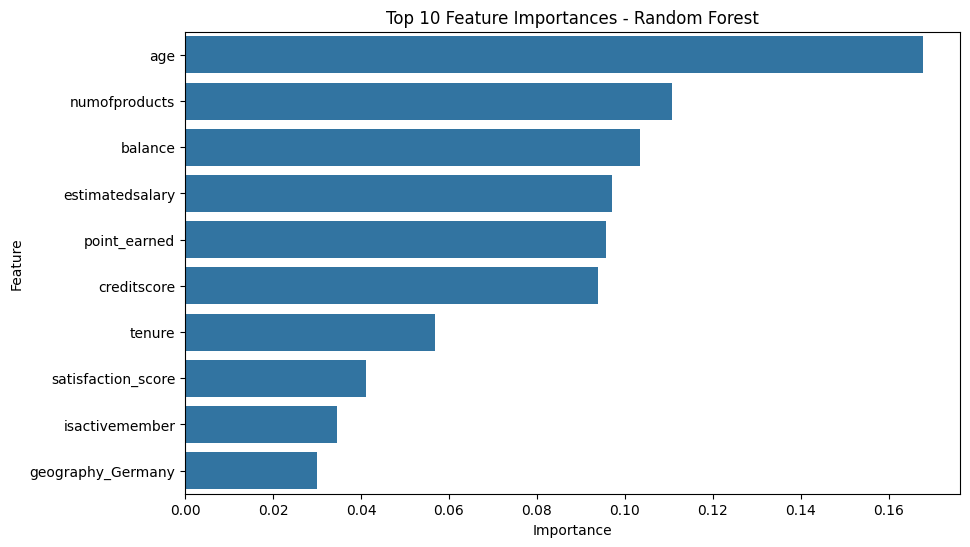

In [ ]:
# ver top de features para random forest
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 variables importantes - Random Forest")

plt.show()

# XGB

In [12]:
#  XGBoost feature importance
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
5,numofproducts,0.223694
7,isactivemember,0.177411
2,age,0.138530
12,geography_Germany,0.081728
4,balance,0.049573
1,gender,0.038221
13,geography_Spain,0.030450
0,creditscore,0.026010
10,point_earned,0.025621
19,age_group_51-60,0.025546


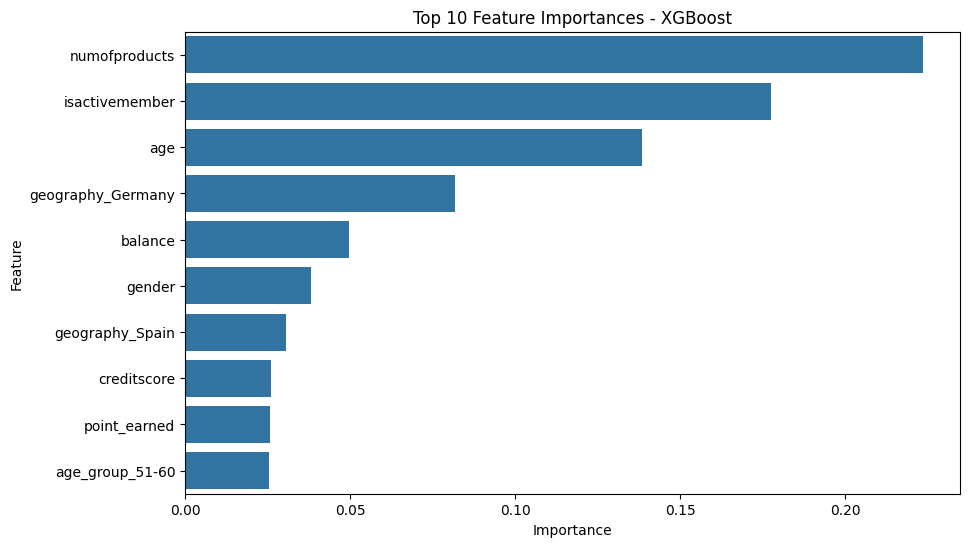

In [13]:
# ver top de features para xgboost
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances - XGBoost")

plt.show()

## Guardado de los modelos mas interesantes y la importancia de variables

In [14]:
joblib.dump(rf, "../models/random_forest.pkl")
joblib.dump(xgb_model, "../models/xgboost.pkl")

['../models/xgboost.pkl']

## Exportar resultados de los modelos y las métricas para Power Bi


In [15]:
results_df.to_csv(
    "../data/processed/model_results.csv",
    index=False
)

print("model_results.csv exported")

model_results.csv exported


In [16]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)

print("feature_importance.csv exported")

feature_importance.csv exported
